# The Connectome Pays Attention: Learning Neural Connectivity Through Self-Supervised Reconstruction

## Abstract

We propose a functional interpretation of a 'connectome' as the self-attention mask over neural tokens. A connectome is a comprehensive map of neural connections in the brain, and may be thought of as its "wiring diagram". We show that connectomes can be seen as the result of optimizing self-supervised objective functions using a diagonal masking self-attention mechanism.

In this implementation, we focus on transcriptomic connectomes that arise from using transcriptomic embeddings of each neuron and training with a masked self-reconstruction objective. The key insight is that individual neurons are discrete tokens, and the task is to reconstruct a neuron's representation using only the representations of other neurons (enforced by diagonal masking).

## Core Hypothesis

The connectome is an attention matrix. Our hypothesis is that this attention matrix can be learned/emerges from creating a task whereby we must reconstruct the representation (i.e. embedding) of each neuron from the embeddings of every other neuron.

**Key Analogy to Sequence Modeling**: 
- In causal language modeling: tokens represent sequence elements, task is next-token prediction, causal mask prevents 'seeing the future'
- In connectome modeling: tokens are individual neurons, task is self-reconstruction via other neurons, diagonal mask prevents 'seeing yourself'


In [ ]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configuration
CONFIG = {
    'embedding_dim': 64,  # D - configurable embedding dimension
    'num_heads': 1,         # Number of attention heads
    'hidden_dim': 256,      # Hidden dimension for attention
    'batch_size': 32,       # Batch size for training
    'learning_rate': 1e-3,  # Learning rate
    'num_epochs': 100,      # Number of training epochs
    'n_samples_per_epoch': 1024,  # Number of random projections per epoch
    'mlp_hidden_dim': 512, # Hidden dimension for random MLPs
    'mlp_n_layers': 3,      # Number of layers in random MLPs
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(f"\nDevice: {'cuda' if torch.cuda.is_available() else 'cpu'}")


Configuration:
  embedding_dim: 64
  num_heads: 1
  hidden_dim: 256
  batch_size: 32
  learning_rate: 0.001
  num_epochs: 200
  n_samples_per_epoch: 1024
  mlp_hidden_dim: 512
  mlp_n_layers: 3

Device: cpu


## 1. Data Preparation and Embedding Generation

We start by loading the single-cell transcriptome data from `Single_Cell_TPM_threshold2.csv`. This dataset contains gene expression data for ~13,669 genes across 128 neuron classes, providing much more granular resolution than bulk-sorted data.

Our approach:
1. Load and preprocess the transcriptome data
2. Apply log1p transformation and standardization
3. Perform PCA to reduce dimensionality to D=1024
4. Generate initial (N, D) embedding matrix where N=128 neuron classes


In [171]:
# Load single-cell transcriptome data
print("Loading transcriptome data...")
df = pd.read_csv('Single_Cell_TPM_threshold2.csv', index_col=0)

print(f"Original data shape: {df.shape}")
print(f"Columns (first 10): {df.columns[:10].tolist()}")
print(f"Index (first 5): {df.index[:5].tolist()}")

# Skip gene metadata columns and get neuron class columns
gene_metadata_cols = ['Gene_Name', 'Sequence_Name', 'Wormbase_ID']
neuron_cols = [col for col in df.columns if col not in gene_metadata_cols]

print(f"\nGene metadata columns: {gene_metadata_cols}")
print(f"Number of neuron classes: {len(neuron_cols)}")
print(f"Neuron classes (first 10): {neuron_cols[:10]}")

# Extract expression data (genes x neurons)
X = df[neuron_cols].values  # Shape: (n_genes, n_neurons)
print(f"\nExpression matrix shape: {X.shape}")

# Transpose to (neurons x genes) format
X = X.T  # Shape: (n_neurons, n_genes)
print(f"Transposed expression matrix shape: {X.shape}")

# Apply log1p transformation to compress dynamic range
X_log = np.log1p(X)
print(f"After log1p transformation - min: {X_log.min():.3f}, max: {X_log.max():.3f}")

# Standardize features (genes)
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X_log)
print(f"After standardization - mean: {X_scaled.mean():.6f}, std: {X_scaled.std():.6f}")

# Store neuron class names
neuron_classes = neuron_cols
N_neurons = len(neuron_classes)
print(f"\nNumber of neuron classes: {N_neurons}")
print(f"Neuron classes: {neuron_classes}")


Loading transcriptome data...
Original data shape: (13669, 130)
Columns (first 10): ['Sequence_Name', 'Wormbase_ID', 'ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM']
Index (first 5): ['aap-1', 'aat-1', 'aat-2', 'aat-3', 'aat-4']

Gene metadata columns: ['Gene_Name', 'Sequence_Name', 'Wormbase_ID']
Number of neuron classes: 128
Neuron classes (first 10): ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY']

Expression matrix shape: (13669, 128)
Transposed expression matrix shape: (128, 13669)
After log1p transformation - min: 0.000, max: 13.028
After standardization - mean: -0.000000, std: 1.000000

Number of neuron classes: 128
Neuron classes: ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASEL', 'ASER', 'ASG', 'ASH', 'ASI', 'ASJ', 'ASK', 'AUA', 'AVA', 'AVB', 'AVD', 'AVE', 'AVF', 'AVG', 'AVH', 'AVJ', 'AVK', 'AVL', 'AVM', 'AWA', 'AWB', 'AWC_OFF', 'AWC_ON', 'BAG', 'BDU', 'CAN', 'CEP', 'DA', 'DA9', 

In [172]:
# Perform PCA to reduce dimensionality
D = CONFIG['embedding_dim']
print(f"Performing PCA to reduce to {D} dimensions...")

# Determine number of components (can't exceed min(n_neurons-1, n_genes))
max_components = min(N_neurons - 1, X_scaled.shape[1])
n_components = min(D, max_components)

print(f"Max possible components: {max_components}")
print(f"Using {n_components} components")

# Fit PCA
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA reduced data shape: {X_pca.shape}")
print(f"Explained variance ratio (first 10 components): {pca.explained_variance_ratio_[:10]}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# If we need more dimensions, pad with zeros
if n_components < D:
    padding = np.zeros((X_pca.shape[0], D - n_components))
    X_embeddings = np.concatenate([X_pca, padding], axis=1)
    print(f"Padded embeddings shape: {X_embeddings.shape}")
else:
    X_embeddings = X_pca
    print(f"Final embeddings shape: {X_embeddings.shape}")


# Store what we'll use as the original embedding matrix for the dataset
layernorm = torch.nn.LayerNorm(X_embeddings.shape[-1], elementwise_affine=False, bias=False)
with torch.no_grad():
    # Normalize embeddings to lie on unit sphere
    original_embeddings = layernorm(torch.tensor(X_embeddings, dtype=torch.float32)).clone()
#  Each neuron's embedding now has 0-mean and unit variance
print(f"\nOriginal embeddings stored. Shape: {original_embeddings.shape}. Dtype: {original_embeddings.dtype}")
print(f"Original embeddings mean (first 3 neurons): {original_embeddings.mean(dim=-1)[:3]}")
print(f"Original embeddings std (first 3 neurons): {original_embeddings.std(dim=-1)[:3]}")


Performing PCA to reduce to 64 dimensions...
Max possible components: 127
Using 64 components
PCA reduced data shape: (128, 64)
Explained variance ratio (first 10 components): [0.08299323 0.05301809 0.02686518 0.02530747 0.02115374 0.01840683
 0.01740082 0.01673128 0.01551487 0.0149022 ]
Total explained variance: 0.762
Final embeddings shape: (128, 64)

Original embeddings stored. Shape: torch.Size([128, 64]). Dtype: torch.float32
Original embeddings mean (first 3 neurons): tensor([-7.4506e-09,  1.3039e-08,  0.0000e+00])
Original embeddings std (first 3 neurons): tensor([1.0079, 1.0079, 1.0079])


## 2. Custom Dataset with Random Projection Augmentation

Since we have only one (N, D) embedding matrix from the original transcriptome data, we need to generate multiple training samples. Our innovation is to create synthetic but meaningful variations using random MLP projections.

**Key insight**: Each random MLP transforms all N neurons identically (N acts as a batch dimension), preserving the relative relationships between neuron embeddings while creating novel projections. This allows generation of effectively unlimited training samples.


In [173]:
class RandomMLP(nn.Module):
    """Random MLP for generating augmented embeddings."""
    
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim=None):
        super().__init__()
        if output_dim is None:
            output_dim = input_dim
            
        layers = []
        current_dim = input_dim
        
        for i in range(n_layers):
            if i == n_layers - 1:
                # Last layer
                layers.append(nn.Linear(current_dim, output_dim))
            else:
                # Hidden layers
                layers.append(nn.Linear(current_dim, hidden_dim))
                # No nonlinerities — just a linear random projection
                # layers.append(nn.Tanh()) 
                current_dim = hidden_dim
        
        # Normalize the output to lie on unit sphere
        layernorm = nn.LayerNorm(output_dim, elementwise_affine=False, bias=False)
        layers.append(layernorm)
                
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)


class TranscriptomeEmbeddingDataset(Dataset):
    """Dataset that generates augmented embeddings using random MLP projections."""
    
    def __init__(self, original_embeddings, n_samples_per_epoch, mlp_hidden_dim, mlp_n_layers, seed=None):
        """
        Args:
            original_embeddings: (N, D) tensor of original neuron embeddings
            n_samples_per_epoch: number of samples to generate per epoch
            mlp_hidden_dim: hidden dimension for random MLPs
            mlp_n_layers: number of layers in random MLPs
            seed: random seed for reproducibility
        """
        self.original_embeddings = original_embeddings  # (N, D)
        self.n_samples_per_epoch = n_samples_per_epoch
        self.mlp_hidden_dim = mlp_hidden_dim
        self.mlp_n_layers = mlp_n_layers
        self.seed = seed
        
        self.N, self.D = original_embeddings.shape
        print(f"Dataset initialized with {self.N} neurons, {self.D} embedding dimensions")
        
        # Pre-compute all samples during initialization
        print(f"Pre-computing {n_samples_per_epoch} augmented samples...")
        self.samples = []
        
        for i in range(n_samples_per_epoch):
            if (i+1) % 100 == 0:
                print(f"  Generating sample {i+1}/{n_samples_per_epoch}")
                
            # Generate a random MLP for this sample
            if self.seed is not None:
                torch.manual_seed(self.seed + i)
                
            random_mlp = RandomMLP(
                input_dim=self.D,
                hidden_dim=self.mlp_hidden_dim,
                n_layers=self.mlp_n_layers,
                output_dim=self.D
            )
            
            # Apply the random MLP to all neurons
            with torch.no_grad():
                augmented_embeddings = random_mlp(self.original_embeddings)  # (N, D)
                
            self.samples.append(augmented_embeddings)
        
        print(f"Pre-computation complete! Stored {len(self.samples)} samples in memory.")
        
    def __len__(self):
        return self.n_samples_per_epoch
    
    def __getitem__(self, idx):
        # Simply return the pre-computed sample
        return self.samples[idx]


# Test the dataset
print("Testing the dataset...")
dataset = TranscriptomeEmbeddingDataset(
    original_embeddings=original_embeddings,
    n_samples_per_epoch=CONFIG['n_samples_per_epoch'],
    mlp_hidden_dim=CONFIG['mlp_hidden_dim'],
    mlp_n_layers=CONFIG['mlp_n_layers'],
    seed=42
)

# Test a few samples
sample = dataset[0]
print(f"\nSample shape: {sample.shape}, dtype: {sample.dtype}")
print(f"Sample mean (first 3 neurons): {sample.mean(dim=-1)[:3]}")
print(f"Sample std (first 3 neurons): {sample.std(dim=-1)[:3]}")

# Test that sample is different from original embeddings
diff = torch.norm(sample - original_embeddings).item()
print(f"Difference between sample and original embeddings: {diff:.3f}")

# Test that different samples are different
sample2 = dataset[1]
diff = torch.norm(sample - sample2).item()
print(f"Difference between samples 0 and 1: {diff:.3f}")

sampleN = dataset[-1]
diff = torch.norm(sample - sampleN).item()
print(f"Difference between samples 0 and {len(dataset)-1}: {diff:.3f}")

# Create data loader
dataloader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)
batch = next(iter(dataloader))
print(f"Batch shape: {batch.shape}")
print(f"Batch dtype: {batch.dtype}")

Testing the dataset...
Dataset initialized with 128 neurons, 64 embedding dimensions
Pre-computing 1024 augmented samples...
  Generating sample 100/1024
  Generating sample 200/1024
  Generating sample 300/1024
  Generating sample 400/1024
  Generating sample 500/1024
  Generating sample 600/1024
  Generating sample 700/1024
  Generating sample 800/1024
  Generating sample 900/1024
  Generating sample 1000/1024
Pre-computation complete! Stored 1024 samples in memory.

Sample shape: torch.Size([128, 64]), dtype: torch.float32
Sample mean (first 3 neurons): tensor([-1.8626e-08, -1.4901e-08,  7.4506e-09])
Sample std (first 3 neurons): tensor([1.0078, 1.0078, 1.0078])
Difference between sample and original embeddings: 126.596
Difference between samples 0 and 1: 127.396
Difference between samples 0 and 1023: 129.869
Batch shape: torch.Size([32, 128, 64])
Batch dtype: torch.float32


### Sanity Check: Preserving Neuron Relationships

Let's verify that our random projection augmentation preserves the relative relationships between neuron embeddings. We'll compare 2D PCA plots of the original embeddings with a sample from our dataset.


Performing sanity check on random projection augmentation...


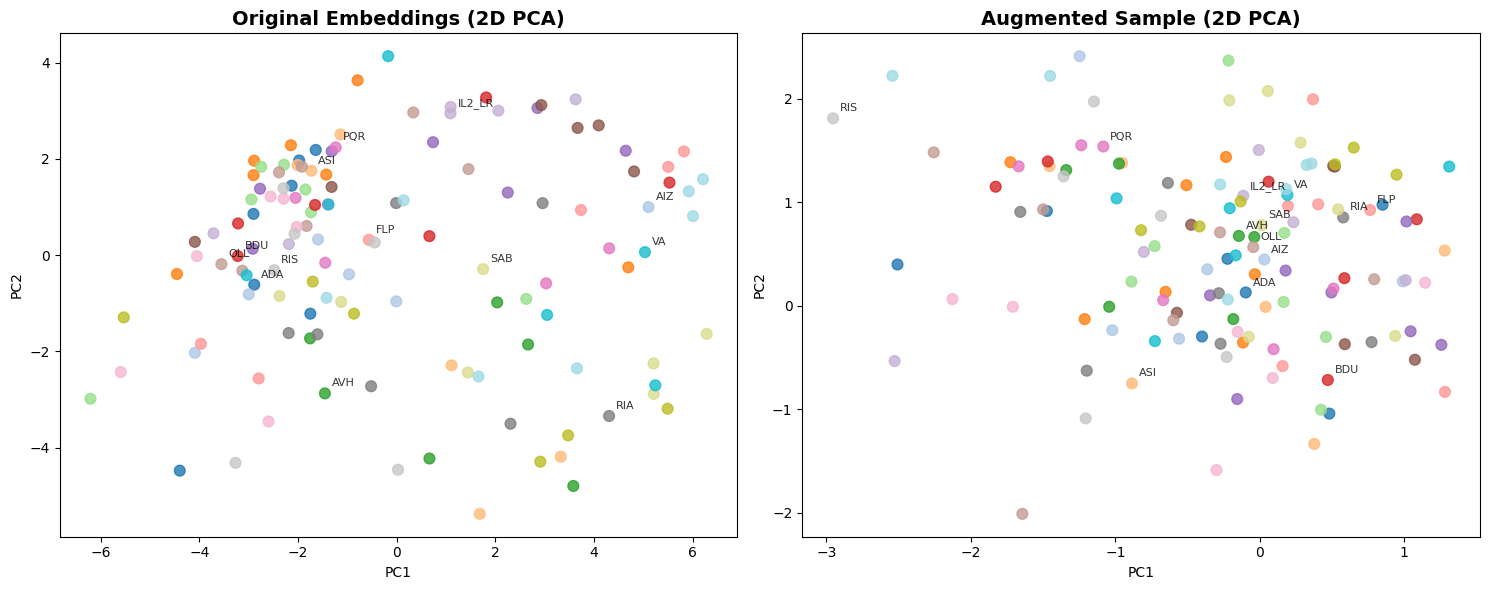


Sanity Check Results:
Correlation between pairwise distances: 0.8641
Original embeddings shape: torch.Size([128, 64])
Sample embeddings shape: (128, 64)

Closest neighbors to AIZ (index 10):
Original: ['RIG', 'I5', 'SMD', 'M5', 'VB01']
Sample:   ['RIG', 'I5', 'SMD', 'VB01', 'MI']
Overlap:  4/5
✓ PASS: High correlation indicates relationships are preserved!


In [174]:
# Sanity check: Compare original embeddings with augmented sample
from sklearn.decomposition import PCA

print("Performing sanity check on random projection augmentation...")

# Get a sample from our dataset
sample_embeddings = sample.numpy()  # Shape: (N, D)

# Perform 2D PCA on both original and sample embeddings
pca_2d = PCA(n_components=2, random_state=42)

# Original embeddings PCA
original_pca = pca_2d.fit_transform(original_embeddings.numpy())

# Sample embeddings PCA (using same PCA object fitted on original)
sample_pca = pca_2d.transform(sample_embeddings)

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot original embeddings
scatter1 = ax1.scatter(original_pca[:, 0], original_pca[:, 1], 
                      c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
ax1.set_title('Original Embeddings (2D PCA)', fontsize=14, fontweight='bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

# Annotate a few points for reference
for i in range(0, len(neuron_classes), 10):  # Annotate every 10th neuron
    ax1.annotate(neuron_classes[i], (original_pca[i, 0], original_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

# Plot sample embeddings
scatter2 = ax2.scatter(sample_pca[:, 0], sample_pca[:, 1], 
                      c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
ax2.set_title('Augmented Sample (2D PCA)', fontsize=14, fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

# Annotate the same points for comparison
for i in range(0, len(neuron_classes), 10):  # Annotate every 10th neuron
    ax2.annotate(neuron_classes[i], (sample_pca[i, 0], sample_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

# Calculate correlation between original and sample embeddings
# Compute pairwise distances between neurons in both embeddings
from scipy.spatial.distance import pdist, squareform

original_distances = pdist(original_embeddings.numpy())
sample_distances = pdist(sample_embeddings)

# Calculate correlation between distance matrices
correlation = np.corrcoef(original_distances, sample_distances)[0, 1]

print(f"\nSanity Check Results:")
print(f"Correlation between pairwise distances: {correlation:.4f}")
print(f"Original embeddings shape: {original_embeddings.shape}")
print(f"Sample embeddings shape: {sample_embeddings.shape}")

# Check if the relative ordering of neurons is preserved
# Find the 5 closest neighbors for a few neurons in both embeddings
test_neuron_idx = 10  # Test with neuron at index 10
original_distances_matrix = squareform(original_distances)
sample_distances_matrix = squareform(sample_distances)

# Get closest neighbors for original
original_neighbors = np.argsort(original_distances_matrix[test_neuron_idx])[1:6]  # Skip self
sample_neighbors = np.argsort(sample_distances_matrix[test_neuron_idx])[1:6]  # Skip self

print(f"\nClosest neighbors to {neuron_classes[test_neuron_idx]} (index {test_neuron_idx}):")
print(f"Original: {[neuron_classes[i] for i in original_neighbors]}")
print(f"Sample:   {[neuron_classes[i] for i in sample_neighbors]}")
print(f"Overlap:  {len(set(original_neighbors) & set(sample_neighbors))}/5")

if correlation > 0.8:
    print("✓ PASS: High correlation indicates relationships are preserved!")
else:
    print("⚠ WARNING: Low correlation - relationships may not be preserved")


## 3. Attention Model Architecture

We implement the `AttentionHeads` module that learns to reconstruct each neuron's embedding using only the embeddings of other neurons. The key innovation is the diagonal masking that prevents self-attention, forcing the model to learn how to combine information from other neurons.

**Architecture**:
- Input: (batch, N, D) tensor of neuron embeddings
- Output: reconstructed embeddings and attention weights
- Diagonal mask: A[i,i] = 0 (prevent self-attention)
- Multi-head attention for learning diverse connectivity patterns


In [175]:
class AttentionHeads(nn.Module):
    def __init__(self, d_model, n_hidden, num_heads=1):
        """
        Args:
            d_model: the dimension of the input tokens (D)
            n_hidden: the hidden dimension for the attention layer
            num_heads: the number of attention heads
        """
        super().__init__()
        # Instead of separate attention heads, use a single linear layer to generate all heads in parallel
        self.W_K = nn.Linear(d_model, n_hidden * num_heads)  # Key projection
        self.W_Q = nn.Linear(d_model, n_hidden * num_heads)  # Query projection
        self.W_V = nn.Linear(d_model, n_hidden * num_heads)  # Value projection
        self.num_heads = num_heads
        self.d_model = d_model
        self.n_hidden = n_hidden
        
        # Output projection to reconstruct original embedding
        self.output_proj = nn.Linear(n_hidden * num_heads, d_model)

    def forward(self, x, attn_mask=None):
        """
        Args:
            x: input token tensor of shape (batch, n_neurons, d_model)
            attn_mask: optional mask tensor of shape (batch, n_neurons, n_neurons)

        Returns:
            reconstructed: reconstructed embeddings of shape (batch, n_neurons, d_model)
            attn_weights: attention weights of shape (batch, num_heads, n_neurons, n_neurons)
            attn_scores: attention scores of shape (batch, num_heads, n_neurons, n_neurons)

        TODO: Consider the case where we use attention scores (instead of weights) to combine values. 
              Would we learn the sign of connections?
        """
        batch_size, n_neurons, d_model = x.shape

        # Compute Q, K, V for all heads in parallel
        Q = (
            self.W_Q(x)
            .reshape(batch_size, n_neurons, self.num_heads, self.n_hidden)
            .transpose(1, 2)
        )  # (batch, num_heads, n_neurons, n_hidden)
        
        K = (
            self.W_K(x)
            .reshape(batch_size, n_neurons, self.num_heads, self.n_hidden)
            .transpose(1, 2)
        )  # (batch, num_heads, n_neurons, n_hidden)
        
        V = (
            self.W_V(x)
            .reshape(batch_size, n_neurons, self.num_heads, self.n_hidden)
            .transpose(1, 2)
        )  # (batch, num_heads, n_neurons, n_hidden)

        # Default to diagonal mask if none provided
        if attn_mask is None:
            # Create diagonal mask: 1 everywhere except diagonal (which is 0)
            device = x.device
            diagonal_mask = (1 - torch.eye(n_neurons)).expand(
                batch_size, -1, -1
            ).to(device)  # (batch, n_neurons, n_neurons)
            attn_mask = diagonal_mask

        # Compute scaled dot-product attention in parallel
        scores = torch.einsum("bhid,bhjd->bhij", Q, K) / (
            self.n_hidden**0.5
        )  # (batch, num_heads, n_neurons, n_neurons)
        
        # Apply mask by setting masked positions to -inf
        inf_masked_scores = scores.masked_fill(
            attn_mask.unsqueeze(1) == 0, float("-inf")
        )

        # Compute masked attention weights
        attn_weights = torch.softmax(
            inf_masked_scores, dim=-1
        )  # (batch, num_heads, n_neurons, n_neurons)

        # We want masked scores but with 0s instead of -infs for visualization
        attn_scores = scores.masked_fill(
            attn_mask.unsqueeze(1) == 0, 0.0
        )  # (batch, num_heads, n_neurons, n_neurons)

        # Apply attention to values
        # attended = torch.einsum("bhij,bhjd->bhid", attn_weights, V)  # (batch, num_heads, n_neurons, n_hidden)
        attended = torch.einsum("bhij,bhjd->bhid", attn_scores, V)  # (batch, num_heads, n_neurons, n_hidden)
        
        # Concatenate heads and project to output dimension
        attended_concat = attended.transpose(1, 2).reshape(
            batch_size, n_neurons, self.num_heads * self.n_hidden
        )  # (batch, n_neurons, num_heads * n_hidden)
        
        reconstructed = self.output_proj(attended_concat)  # (batch, n_neurons, d_model)

        return reconstructed, attn_weights, attn_scores


# Test the attention model
print("Testing AttentionHeads model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model
model = AttentionHeads(
    d_model=CONFIG['embedding_dim'],
    n_hidden=CONFIG['hidden_dim'],
    num_heads=CONFIG['num_heads']
).to(device)

print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")

# Test with a batch
test_batch = batch.to(device)  # (batch_size, n_neurons, d_model)
print(f"Test batch shape: {test_batch.shape}")

with torch.no_grad():
    reconstructed, attn_weights, attn_scores = model(test_batch)
    
print(f"Reconstructed shape: {reconstructed.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"Attention scores shape: {attn_scores.shape}")

# Check that diagonal is zero in attention weights
diagonal_weights = torch.diagonal(attn_weights[0, 0], dim1=0, dim2=1)
print(f"Diagonal attention weights (should be ~0): {diagonal_weights[:5]}")

# Check reconstruction error
reconstruction_error = torch.norm(test_batch - reconstructed, dim=-1).mean()
print(f"Initial reconstruction error: {reconstruction_error:.3f}")


Testing AttentionHeads model...
Using device: cpu
Model created with 66368 parameters
Test batch shape: torch.Size([32, 128, 64])
Reconstructed shape: torch.Size([32, 128, 64])
Attention weights shape: torch.Size([32, 1, 128, 128])
Attention scores shape: torch.Size([32, 1, 128, 128])
Diagonal attention weights (should be ~0): tensor([0., 0., 0., 0., 0.])
Initial reconstruction error: 29.201


## 4. Training Loop with Reconstruction Loss

We train the attention model to minimize the reconstruction error between original and reconstructed embeddings. The key insight is that the model must learn to combine information from other neurons to reconstruct each neuron's embedding, with the learned attention weights representing the "connectome".


In [176]:
# Set up training
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50)

# Create datasets once outside the training loop
print("Creating training and validation datasets...")
train_dataset = TranscriptomeEmbeddingDataset(
    original_embeddings=original_embeddings,
    n_samples_per_epoch=CONFIG['n_samples_per_epoch'],
    mlp_hidden_dim=CONFIG['mlp_hidden_dim'],
    mlp_n_layers=CONFIG['mlp_n_layers'],
    seed=42
)

val_dataset = TranscriptomeEmbeddingDataset(
    original_embeddings=original_embeddings,
    n_samples_per_epoch=200,  # Smaller validation set
    mlp_hidden_dim=CONFIG['mlp_hidden_dim'],
    mlp_n_layers=CONFIG['mlp_n_layers'],
    seed=42 + len(train_dataset)  # Different seed for validation
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

# Training history
train_losses = []
val_losses = []
attention_sparsity = []

print("Starting training...")
print(f"Training for {CONFIG['num_epochs']} epochs")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Learning rate: {CONFIG['learning_rate']}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Training loop
import time

for epoch in range(CONFIG['num_epochs']):
    epoch_start_time = time.time()
    model.train()
    epoch_train_loss = 0.0
    epoch_attention_sparsity = 0.0
    num_batches = 0
    
    print(f"\nEpoch {epoch+1}/{CONFIG['num_epochs']} - Training phase")
    train_start_time = time.time()
    
    for batch_idx, batch in enumerate(train_loader):
        if (batch_idx + 1) % 10 == 0:  # Print every 10 batches
            print(f"  Batch {batch_idx+1}/{len(train_loader)}")
            
        batch = batch.to(device)
        
        # Forward pass
        reconstructed, attn_weights, attn_scores = model(batch)
        
        # Compute loss
        loss = criterion(reconstructed, batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        epoch_train_loss += loss.item()
        
        # Compute attention sparsity (fraction of near-zero attention weights)
        with torch.no_grad():
            sparsity = (attn_weights < 0.01).float().mean().item()
            epoch_attention_sparsity += sparsity
        
        num_batches += 1
    
    # Average metrics for this epoch
    avg_train_loss = epoch_train_loss / num_batches
    avg_sparsity = epoch_attention_sparsity / num_batches
    
    train_losses.append(avg_train_loss)
    attention_sparsity.append(avg_sparsity)
    
    # Validation
    train_time = time.time() - train_start_time
    print(f"Epoch {epoch+1}/{CONFIG['num_epochs']} - Validation phase (Training took {train_time:.2f}s)")
    val_start_time = time.time()
    model.eval()
    val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            if (batch_idx + 1) % 5 == 0:  # Print every 5 batches for validation
                print(f"  Val batch {batch_idx+1}/{len(val_loader)}")
            batch = batch.to(device)
            reconstructed, _, _ = model(batch)
            loss = criterion(reconstructed, batch)
            val_loss += loss.item()
            val_batches += 1
    
    avg_val_loss = val_loss / val_batches
    val_losses.append(avg_val_loss)
    
    # Update learning rate
    scheduler.step(avg_val_loss)
    
    # Print progress
    val_time = time.time() - val_start_time
    epoch_time = time.time() - epoch_start_time
    
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch+1}/{CONFIG['num_epochs']}: "
              f"Train Loss: {avg_train_loss:.6f}, "
              f"Val Loss: {avg_val_loss:.6f}, "
              f"Attention Sparsity: {avg_sparsity:.3f}, "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"  Timing - Train: {train_time:.2f}s, Val: {val_time:.2f}s, Total: {epoch_time:.2f}s")
    elif (epoch + 1) % 10 == 0:  # Print timing every 10 epochs
        print(f"Epoch {epoch+1} completed in {epoch_time:.2f}s (Train: {train_time:.2f}s, Val: {val_time:.2f}s)")

print("Training completed!")


Creating training and validation datasets...
Dataset initialized with 128 neurons, 64 embedding dimensions
Pre-computing 1024 augmented samples...
  Generating sample 100/1024
  Generating sample 200/1024
  Generating sample 300/1024
  Generating sample 400/1024
  Generating sample 500/1024
  Generating sample 600/1024
  Generating sample 700/1024
  Generating sample 800/1024
  Generating sample 900/1024
  Generating sample 1000/1024
Pre-computation complete! Stored 1024 samples in memory.
Dataset initialized with 128 neurons, 64 embedding dimensions
Pre-computing 200 augmented samples...
  Generating sample 100/200
  Generating sample 200/200
Pre-computation complete! Stored 200 samples in memory.
Starting training...
Training for 200 epochs
Batch size: 32
Learning rate: 0.001
Training samples: 1024
Validation samples: 200

Epoch 1/200 - Training phase
  Batch 10/32
  Batch 20/32
  Batch 30/32
Epoch 1/200 - Validation phase (Training took 0.90s)
  Val batch 5/7
Epoch 1/200: Train Loss

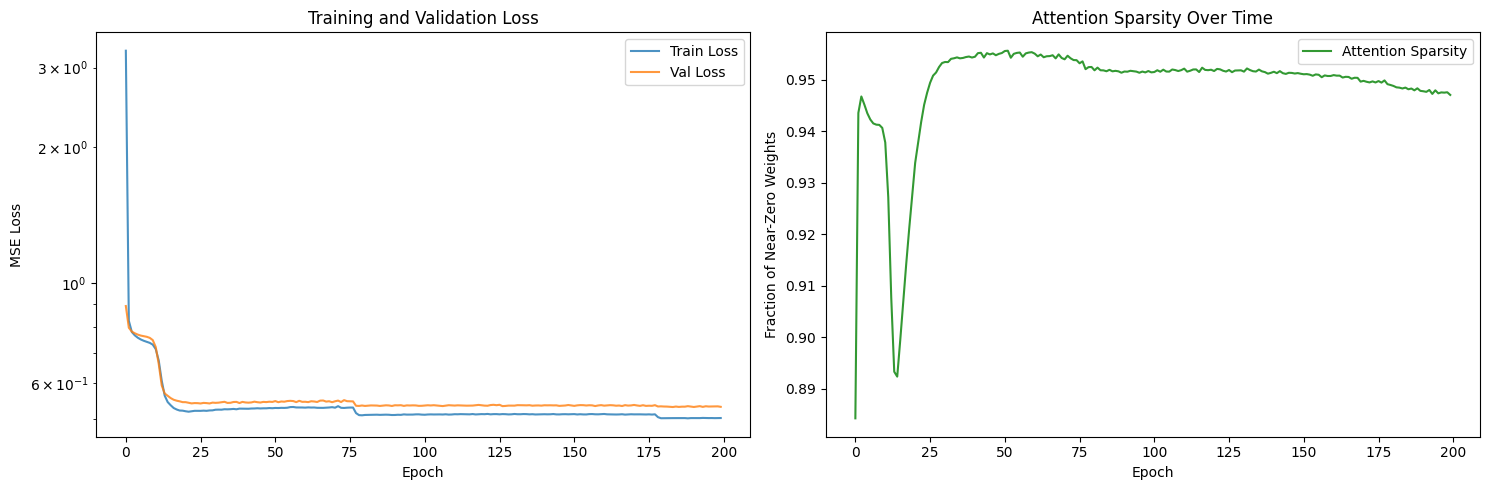


Final Training Loss: 0.502870
Final Validation Loss: 0.532417
Final Attention Sparsity: 0.947
Best Validation Loss: 0.531884 (Epoch 184)


In [177]:
# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', alpha=0.8)
plt.plot(val_losses, label='Val Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(attention_sparsity, label='Attention Sparsity', color='green', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Fraction of Near-Zero Weights')
plt.title('Attention Sparsity Over Time')
plt.legend()

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Loss: {train_losses[-1]:.6f}")
print(f"Final Validation Loss: {val_losses[-1]:.6f}")
print(f"Final Attention Sparsity: {attention_sparsity[-1]:.3f}")
print(f"Best Validation Loss: {min(val_losses):.6f} (Epoch {val_losses.index(min(val_losses))+1})")


## 5. Linear Regression Baseline

To validate that the nonlinear attention mechanism captures something beyond simple linear relationships, we implement a multiple linear regression baseline. For each neuron, we regress its embedding onto all other neuron embeddings, with the regression coefficients forming an alternative "connectome" matrix.


In [178]:
# Linear Regression Baseline (train on augmented data, evaluate on original)
print("Implementing linear regression baseline...")

# 1) Prepare training data from augmented projections
n_baseline_samples = 2000
baseline_dataset = TranscriptomeEmbeddingDataset(
    original_embeddings=original_embeddings,
    n_samples_per_epoch=n_baseline_samples,
    mlp_hidden_dim=CONFIG['mlp_hidden_dim'],
    mlp_n_layers=CONFIG['mlp_n_layers'],
    seed=999
)

all_samples = []
for i in range(len(baseline_dataset)):
    all_samples.append(baseline_dataset[i].numpy())
X_baseline = np.stack(all_samples)  # (n_samples, N, D)
print(f"Baseline training data shape: {X_baseline.shape}")

# Flatten so we can slice per neuron across samples
N, D = original_embeddings.shape
X_flat = X_baseline.reshape(-1, D)  # (n_samples * N, D)
print(f"Flattened data shape: {X_flat.shape}")

# 2) Fit per-neuron Ridge on the augmented data and build linear connectome
ridge_models = [None] * N
linear_connectome = np.zeros((N, N))
linear_train_errors = []

print("Fitting Ridge per neuron on augmented data...")
for i in range(N):
    # Targets: embeddings for neuron i across all samples
    y_train = X_flat[i::N]  # shape: (n_samples, D)

    # Features: concatenated embeddings of all other neurons across samples
    X_features_train_blocks = [X_flat[j::N] for j in range(N) if j != i]  # list of (n_samples, D)
    X_features_train = np.concatenate(X_features_train_blocks, axis=1)     # (n_samples, (N-1)*D)

    ridge_i = Ridge(alpha=1.0, random_state=42)
    ridge_i.fit(X_features_train, y_train)
    ridge_models[i] = ridge_i

    # Train MSE for reporting
    y_pred_train = ridge_i.predict(X_features_train)
    mse_train_i = mean_squared_error(y_train, y_pred_train)
    linear_train_errors.append(mse_train_i)

    # Aggregate per-source coefficient magnitudes into a (N, N) matrix
    coeff_idx = 0
    for j in range(N):
        if j == i:
            continue
        coeff_block = ridge_i.coef_[:, coeff_idx*D:(coeff_idx+1)*D]  # (D, D)
        linear_connectome[i, j] = np.mean(np.abs(coeff_block))
        coeff_idx += 1

print(f"Linear baseline train MSE (augmented): {np.mean(linear_train_errors):.6f}")
print(f"Linear connectome shape: {linear_connectome.shape}")
print(f"Linear connectome stats - mean: {linear_connectome.mean():.6f}, std: {linear_connectome.std():.6f}")

# 3) Evaluate the trained Ridge models on the original embeddings (no refit)
print("\nEvaluating linear baseline on original embeddings...")
X_orig = original_embeddings.numpy()  # (N, D)

linear_mse_on_original_per_neuron = []
for i in range(N):
    # Build a single-row feature vector from original embeddings of all other neurons
    X_features_orig_blocks = [X_orig[j:j+1, :] for j in range(N) if j != i]  # list of (1, D)
    X_features_orig = np.concatenate(X_features_orig_blocks, axis=1)         # (1, (N-1)*D)

    y_pred_orig = ridge_models[i].predict(X_features_orig)                   # (1, D)
    mse_i = mean_squared_error(X_orig[i:i+1, :], y_pred_orig)
    linear_mse_on_original_per_neuron.append(mse_i)

linear_mse_on_original = float(np.mean(linear_mse_on_original_per_neuron))
print(f"Linear baseline MSE on original embeddings: {linear_mse_on_original:.6f}")

Implementing linear regression baseline...
Dataset initialized with 128 neurons, 64 embedding dimensions
Pre-computing 2000 augmented samples...
  Generating sample 100/2000
  Generating sample 200/2000
  Generating sample 300/2000
  Generating sample 400/2000
  Generating sample 500/2000
  Generating sample 600/2000
  Generating sample 700/2000
  Generating sample 800/2000
  Generating sample 900/2000
  Generating sample 1000/2000
  Generating sample 1100/2000
  Generating sample 1200/2000
  Generating sample 1300/2000
  Generating sample 1400/2000
  Generating sample 1500/2000
  Generating sample 1600/2000
  Generating sample 1700/2000
  Generating sample 1800/2000
  Generating sample 1900/2000
  Generating sample 2000/2000
Pre-computation complete! Stored 2000 samples in memory.
Baseline training data shape: (2000, 128, 64)
Flattened data shape: (256000, 64)
Fitting Ridge per neuron on augmented data...
Linear baseline train MSE (augmented): 0.000000
Linear connectome shape: (128, 1

## 6. Visualization of Learned Attention Matrices

Now we visualize the learned attention patterns and compare them with the linear regression baseline. The attention weights represent our learned "connectome" - how much each neuron needs to attend to every other neuron for reconstruction.


Extracting learned attention weights on original embeddings...
Reconstruction MSE on original embeddings: 0.664636
Learned attention matrix shape: (128, 128)
Attention matrix stats - mean: 0.007812, std: 0.001324
Attention matrix range: [0.000000, 0.015146]


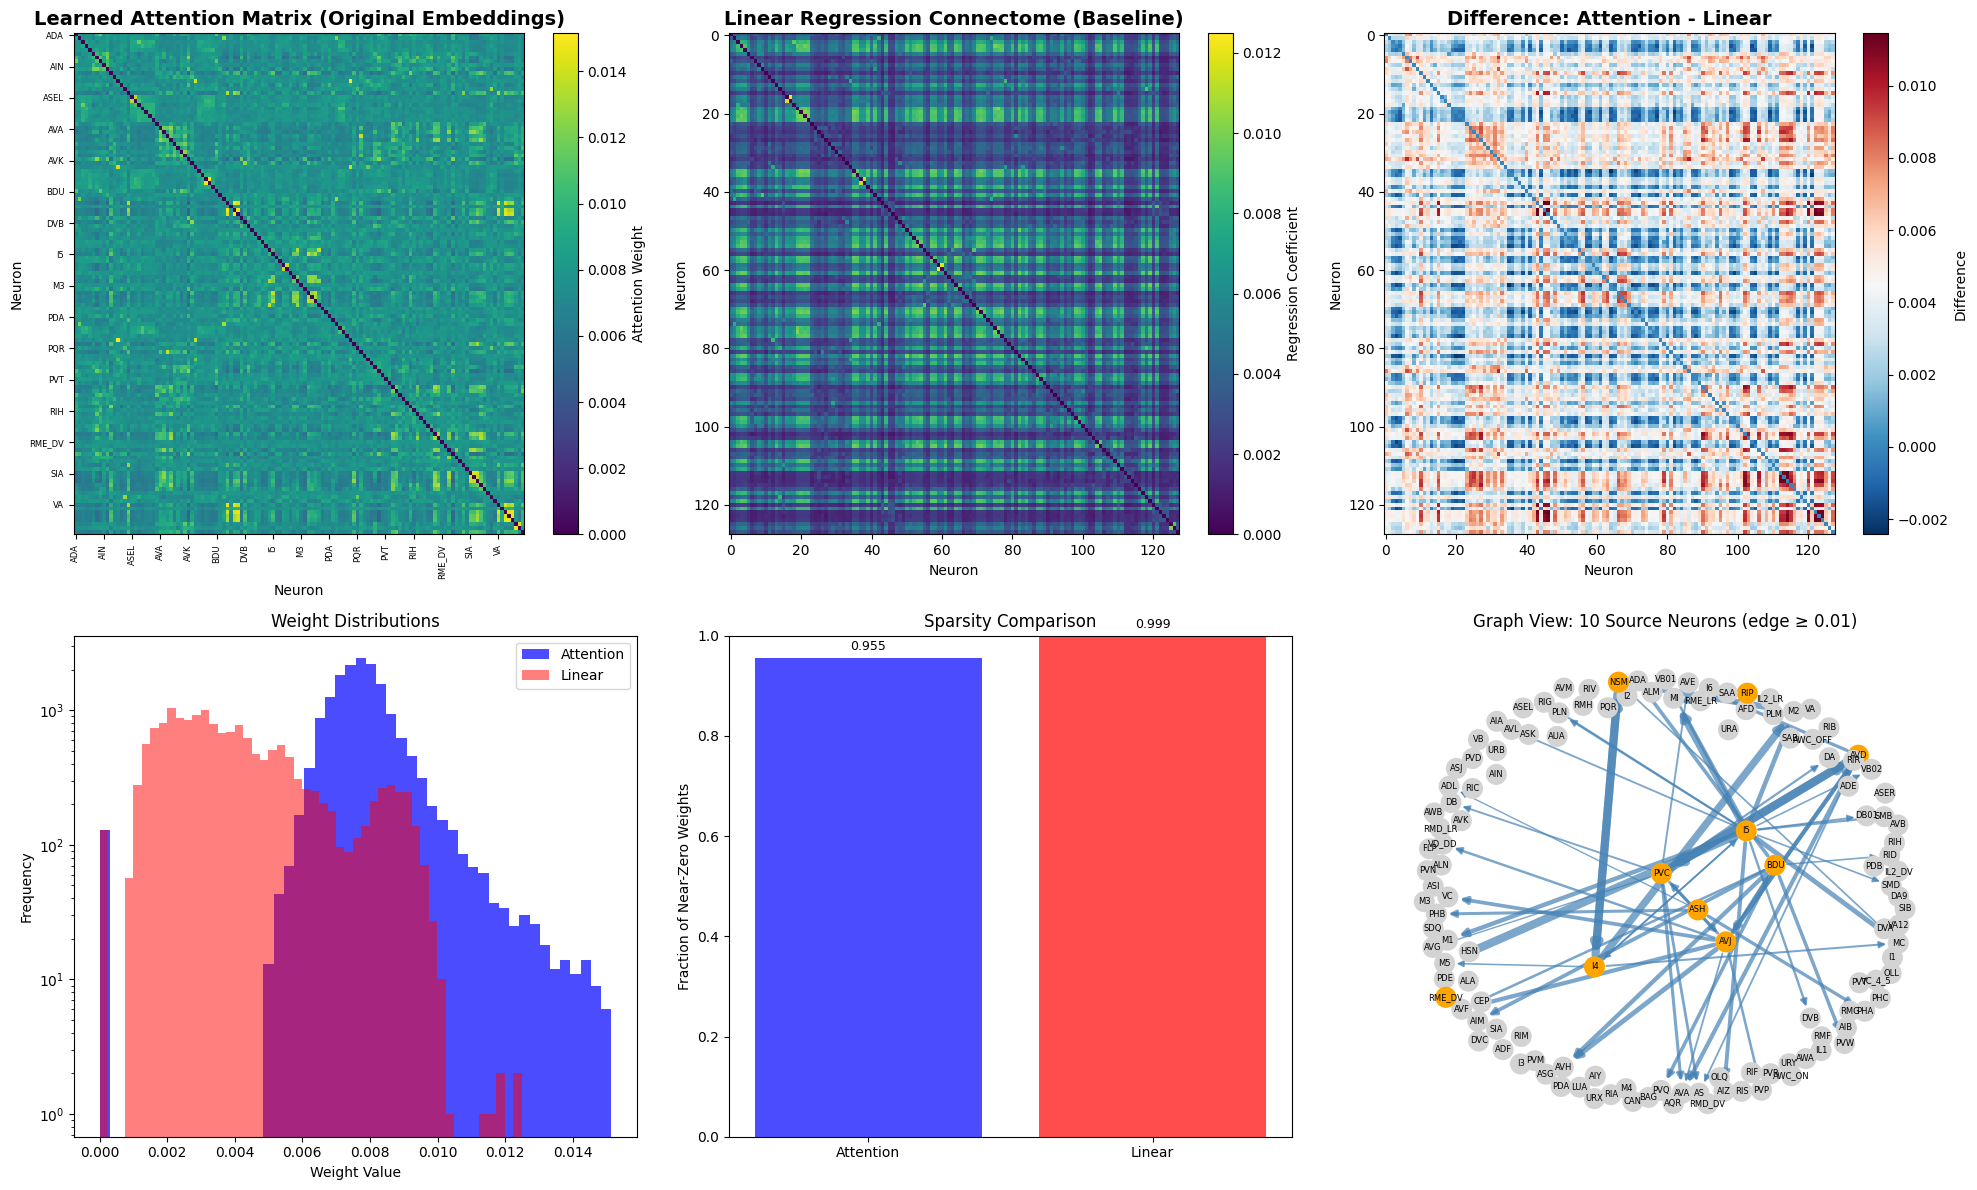


Summary (Original Embeddings):
Reconstruction MSE (attention): 0.664636
Linear matrix mean: 0.004048, std: 0.002166
Attention matrix sparsity@0.01: 0.955


In [180]:
# Evaluate learned attention on original embeddings and visualize
import networkx as nx

print("Extracting learned attention weights on original embeddings...")
model.eval()
with torch.no_grad():
    # Use the original embeddings as the test "batch" (batch size = 1)
    test_batch = original_embeddings.unsqueeze(0).to(device)  # (1, N, D)
    reconstructed_orig, attn_weights, attn_scores = model(test_batch)

# Compute reconstruction MSE on original embeddings
mse_orig = torch.mean((reconstructed_orig - test_batch)**2).item()
print(f"Reconstruction MSE on original embeddings: {mse_orig:.6f}")

# Average attention across heads and batch
avg_attention = attn_weights.mean(dim=(0, 1)).cpu().numpy()  # (N, N)
attention_matrix = avg_attention

print(f"Learned attention matrix shape: {attention_matrix.shape}")
print(f"Attention matrix stats - mean: {attention_matrix.mean():.6f}, std: {attention_matrix.std():.6f}")
print(f"Attention matrix range: [{attention_matrix.min():.6f}, {attention_matrix.max():.6f}]")

# Visualization: heatmaps + distributions + sparsity + top connections + graph view
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1) Learned attention matrix with sparsified tick labels
im1 = axes[0, 0].imshow(attention_matrix, cmap='viridis', aspect='auto')
axes[0, 0].set_title('Learned Attention Matrix (Original Embeddings)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Neuron')
axes[0, 0].set_ylabel('Neuron')
plt.colorbar(im1, ax=axes[0, 0], label='Attention Weight')
# Label every k-th tick to reduce clutter
k = max(1, len(neuron_classes) // 16)  # ~16 labels per axis
xticks = np.arange(0, len(neuron_classes), k)
axes[0, 0].set_xticks(xticks)
axes[0, 0].set_xticklabels([neuron_classes[i] for i in xticks], fontsize=6, rotation=90)
axes[0, 0].set_yticks(xticks)
axes[0, 0].set_yticklabels([neuron_classes[i] for i in xticks], fontsize=6)

# 2) Linear baseline connectome (if computed); otherwise show placeholder
if 'linear_connectome' in globals():
    im2 = axes[0, 1].imshow(linear_connectome, cmap='viridis', aspect='auto')
    axes[0, 1].set_title('Linear Regression Connectome (Baseline)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Neuron'); axes[0, 1].set_ylabel('Neuron')
    plt.colorbar(im2, ax=axes[0, 1], label='Regression Coefficient')
else:
    axes[0, 1].axis('off')
    axes[0, 1].text(0.5, 0.5, 'Linear baseline not yet computed', ha='center', va='center')

# 3) Difference: Attention - Linear (if available)
if 'linear_connectome' in globals():
    diff_matrix = attention_matrix - linear_connectome
    im3 = axes[0, 2].imshow(diff_matrix, cmap='RdBu_r', aspect='auto')
    axes[0, 2].set_title('Difference: Attention - Linear', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Neuron'); axes[0, 2].set_ylabel('Neuron')
    plt.colorbar(im3, ax=axes[0, 2], label='Difference')
else:
    axes[0, 2].axis('off')

# 4) Weight distributions
axes[1, 0].hist(attention_matrix.flatten(), bins=50, alpha=0.7, color='blue', label='Attention')
if 'linear_connectome' in globals():
    axes[1, 0].hist(linear_connectome.flatten(), bins=50, alpha=0.5, color='red', label='Linear')
axes[1, 0].set_xlabel('Weight Value'); axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Weight Distributions'); axes[1, 0].legend(); axes[1, 0].set_yscale('log')

# 5) Sparsity bars
attn_sparsity_thresh = 0.01
attention_sparsity_val = (attention_matrix < attn_sparsity_thresh).sum() / attention_matrix.size
bars_labels = ['Attention']; bars_values = [attention_sparsity_val]
if 'linear_connectome' in globals():
    linear_sparsity_val = (linear_connectome < attn_sparsity_thresh).sum() / linear_connectome.size
    bars_labels.append('Linear'); bars_values.append(linear_sparsity_val)
bars = axes[1, 1].bar(bars_labels, bars_values, color=['blue', 'red'][:len(bars_values)], alpha=0.7)
axes[1, 1].set_ylabel('Fraction of Near-Zero Weights'); axes[1, 1].set_title('Sparsity Comparison'); axes[1, 1].set_ylim(0, 1)
for bar, value in zip(bars, bars_values):
    axes[1, 1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

# 6) Graph plot for 10 randomly selected source neurons (edges filtered by threshold)
np.random.seed(42)
num_sources = 10
edge_thresh = 0.01  # filter weak edges (same as sparsity threshold)
sources = np.random.choice(len(neuron_classes), size=num_sources, replace=False)
G = nx.DiGraph()
# Add nodes
for idx in range(len(neuron_classes)):
    G.add_node(idx, label=neuron_classes[idx])

# Add edges from selected sources above threshold (exclude self)
for i in sources:
    for j in range(len(neuron_classes)):
        if i == j: 
            continue
        w = attention_matrix[i, j]
        if w >= edge_thresh:
            G.add_edge(i, j, weight=w)

# Node positions (spring layout)
pos = nx.spring_layout(G, seed=42, k=0.3)
# Draw nodes (highlight selected sources)
node_colors = ['orange' if n in sources else 'lightgray' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors, ax=axes[1, 2])
# Draw edges with widths ~ weight
if G.number_of_edges() > 0:
    weights = np.array([d['weight'] for (_, _, d) in G.edges(data=True)])
    widths = 1.0 + 5.0 * (weights - weights.min()) / (np.ptp(weights) + 1e-8)
    nx.draw_networkx_edges(G, pos, width=widths, edge_color='steelblue', alpha=0.7, arrows=True, ax=axes[1, 2])
# Draw labels for nodes; keep small
labels = {n: neuron_classes[n] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=6, ax=axes[1, 2])
axes[1, 2].set_title(f'Graph View: {num_sources} Source Neurons (edge ≥ {edge_thresh})')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\nSummary (Original Embeddings):")
print(f"Reconstruction MSE (attention): {mse_orig:.6f}")
if 'linear_connectome' in globals():
    print(f"Linear matrix mean: {linear_connectome.mean():.6f}, std: {linear_connectome.std():.6f}")
print(f"Attention matrix sparsity@{attn_sparsity_thresh}: {attention_sparsity_val:.3f}")

## 7. Results and Interpretation

Let's analyze the results and interpret what we've learned about the connectome as attention framework.


In [181]:
# Detailed analysis of results
print("="*60)
print("CONNECTOME AS ATTENTION: RESULTS ANALYSIS")
print("="*60)

# 1. Reconstruction Performance (evaluated on original embeddings)
print("\n1. RECONSTRUCTION PERFORMANCE (Original Embeddings)")
print("-" * 30)
print(f"Attention Model MSE (original): {mse_orig:.6f}")
if 'linear_mse_on_original' in globals():
    print(f"Linear Baseline MSE (original): {linear_mse_on_original:.6f}")
    improvement = (linear_mse_on_original - mse_orig) / max(linear_mse_on_original, 1e-8) * 100
    print(f"Relative improvement (attention vs linear): {improvement:+.1f}%")
else:
    print("Linear baseline (original) not available in this run.")

# 2. Attention Matrix Analysis
print("\n2. LEARNED ATTENTION MATRIX ANALYSIS")
print("-" * 30)
print(f"Matrix Shape: {attention_matrix.shape}")
print(f"Mean Attention Weight: {attention_matrix.mean():.6f}")
print(f"Std Attention Weight: {attention_matrix.std():.6f}")
print(f"Max Attention Weight: {attention_matrix.max():.6f}")
print(f"Min Attention Weight: {attention_matrix.min():.6f}")
diag_mean = np.diag(attention_matrix).mean()
print(f"Diagonal Mean (should be ~0): {diag_mean:.6f}")

# 3. Sparsity Analysis
print("\n3. SPARSITY ANALYSIS")
print("-" * 30)
sparsity_thresh = 0.01
attn_sparsity = (attention_matrix < sparsity_thresh).sum() / attention_matrix.size
print(f"Attention Matrix Sparsity@{sparsity_thresh}: {attn_sparsity:.3f}")
if 'linear_connectome' in globals():
    linear_sparsity = (linear_connectome < sparsity_thresh).sum() / linear_connectome.size
    print(f"Linear Matrix Sparsity@{sparsity_thresh}: {linear_sparsity:.3f}")

# 4. Top Connections (off-diagonal)
print("\n4. TOP ATTENTION CONNECTIONS")
print("-" * 30)
mask = np.eye(attention_matrix.shape[0], dtype=bool)
attention_off_diag = attention_matrix.copy()
attention_off_diag[mask] = 0
top_k = 10
flat_indices = np.argsort(attention_off_diag.flatten())[-top_k:]
top_connections = [(idx // attention_matrix.shape[1], idx % attention_matrix.shape[1]) for idx in flat_indices]
for rank, (src, tgt) in enumerate(top_connections, 1):
    weight = attention_off_diag[src, tgt]
    src_name = neuron_classes[src] if src < len(neuron_classes) else f"Neuron_{src}"
    tgt_name = neuron_classes[tgt] if tgt < len(neuron_classes) else f"Neuron_{tgt}"
    print(f"  {rank:2d}. {src_name} → {tgt_name}: {weight:.6f}")

# 5. Neuron-wise totals
print("\n5. NEURON-WISE TOTALS")
print("-" * 30)
incoming = attention_matrix.sum(axis=0)
outgoing = attention_matrix.sum(axis=1)
top_in = np.argsort(incoming)[-5:]
top_out = np.argsort(outgoing)[-5:]
print("Top 5 most attended-to neurons (incoming):")
for i, idx in enumerate(top_in, 1):
    print(f"  {i}. {neuron_classes[idx]}: {incoming[idx]:.6f}")
print("\nTop 5 most attending neurons (outgoing):")
for i, idx in enumerate(top_out, 1):
    print(f"  {i}. {neuron_classes[idx]}: {outgoing[idx]:.6f}")

# 6. Multi-head (if applicable)
if CONFIG['num_heads'] > 1:
    print("\n6. MULTI-HEAD ATTENTION ANALYSIS")
    print("-" * 30)
    with torch.no_grad():
        _, attn_w_perhead, _ = model(original_embeddings.unsqueeze(0).to(device))
        for head in range(CONFIG['num_heads']):
            head_mat = attn_w_perhead[0, head].cpu().numpy()
            print(f"  Head {head+1}: mean={head_mat.mean():.6f}, std={head_mat.std():.6f}")

# 7. Training Dynamics (from training with augmented data)
print("\n7. TRAINING DYNAMICS (Augmented Data)")
print("-" * 30)
if len(train_losses) > 0 and len(val_losses) > 0:
    print(f"Epochs: {len(train_losses)}")
    print(f"Initial training loss: {train_losses[0]:.6f}")
    print(f"Final training loss: {train_losses[-1]:.6f}")
    print(f"Best validation loss: {min(val_losses):.6f} (epoch {val_losses.index(min(val_losses))+1})")
else:
    print("Training curves not available in this run.")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

CONNECTOME AS ATTENTION: RESULTS ANALYSIS

1. RECONSTRUCTION PERFORMANCE (Original Embeddings)
------------------------------
Attention Model MSE (original): 0.664636
Linear Baseline MSE (original): 0.710708
Relative improvement (attention vs linear): +6.5%

2. LEARNED ATTENTION MATRIX ANALYSIS
------------------------------
Matrix Shape: (128, 128)
Mean Attention Weight: 0.007812
Std Attention Weight: 0.001324
Max Attention Weight: 0.015146
Min Attention Weight: 0.000000
Diagonal Mean (should be ~0): 0.000000

3. SPARSITY ANALYSIS
------------------------------
Attention Matrix Sparsity@0.01: 0.955
Linear Matrix Sparsity@0.01: 0.999

4. TOP ATTENTION CONNECTIONS
------------------------------
   1. VB → VB02: 0.014683
   2. DB01 → DB: 0.014767
   3. DB → DB01: 0.014779
   4. VC_4_5 → VC: 0.014834
   5. AWC_ON → AWC_OFF: 0.014857
   6. AWC_OFF → AWC_ON: 0.014919
   7. DA → DB: 0.014941
   8. DB → DA: 0.014998
   9. ALM → PLM: 0.015091
  10. PLM → ALM: 0.015146

5. NEURON-WISE TOTALS
--